# Multi-species entropy flow under a shared-density constraint

This notebook generates `fig:gradflow-multispecies-entropy-flow`. It illustrates a product Wasserstein gradient flow for a vector of positive densities
$$
    \alpha=(\alpha_1,\ldots,\alpha_p), \qquad
    \mathcal W_{2,\oplus}^2(\alpha,\eta)=\sum_{i=1}^p m_i W_2^2\!\left(\frac{\alpha_i}{m_i},\frac{\eta_i}{m_i}\right),
$$
where $m_i=\alpha_i(\Omega)$ is the fixed mass of species $i$. In the numerical example the species form a pointwise partition of a uniform total density,
$$
    \sum_{i=1}^p \rho_i(x)=1 .
$$
For the separable Shannon entropy $F(\alpha)=\sum_i\int \rho_i\log\rho_i\,dx$ on a periodic interval, the pressure enforcing the constraint is constant. Each component therefore follows the heat equation, while the stacked sum remains exactly flat.

The three panels below show $p=2$, $p=3$ and $p=5$ species. Each panel stacks four time snapshots vertically, using colored bands for the different species.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    GRAY,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "gradflow-multispecies-entropy-flow"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)

## Periodic heat evolution

The initial states are smooth positive partitions of unity on the periodic interval.  We construct them by applying a softmax to a few localized bumps and low-frequency oscillations.  The heat equation is then solved exactly in Fourier variables, which keeps the computation deterministic and avoids numerical diffusion artifacts.

In [2]:
N = 900
x = np.linspace(0.0, 1.0, N, endpoint=False)
dx = 1.0 / N
freq = np.fft.fftfreq(N, d=dx)
times = np.array([0.0, 0.0015, 0.008, 0.04])


def species_colors(p):
    if p == 2:
        return [RED, BLUE]
    return [interp_color(i / (p - 1), RED, BLUE) for i in range(p)]


def gaussian_periodic(x, center, sigma):
    dist = ((x - center + 0.5) % 1.0) - 0.5
    return np.exp(-0.5 * (dist / sigma) ** 2)


def initial_partition(p):
    centers = np.linspace(0.14, 0.86, p)
    centers = (centers + 0.035 * np.sin(1.7 * np.arange(p))) % 1.0
    widths = 0.055 + 0.012 * (np.arange(p) % 3)
    logits = []
    for i, (center, width) in enumerate(zip(centers, widths)):
        bump = 2.6 * gaussian_periodic(x, center, width)
        shoulder = 1.4 * gaussian_periodic(x, (center + 0.22 + 0.04 * np.cos(i)) % 1.0, 1.35 * width)
        wave = 0.55 * np.sin(2 * np.pi * (i + 1) * x + 0.8 * i)
        wave += 0.30 * np.cos(2 * np.pi * (2 * i + 1) * x - 0.4 * i)
        logits.append(bump + 0.45 * shoulder + wave)
    logits = np.vstack(logits)
    logits -= logits.max(axis=0, keepdims=True)
    weights = np.exp(logits)
    rho = weights / weights.sum(axis=0, keepdims=True)
    return rho


def heat_flow(rho0, t):
    if t == 0:
        return rho0.copy()
    multiplier = np.exp(-(2 * np.pi * freq) ** 2 * t)
    rho = np.empty_like(rho0)
    for i in range(rho0.shape[0]):
        # The same heat semigroup is applied to every species, hence both
        # component masses and the pointwise total density are preserved.
        rho[i] = np.real(np.fft.ifft(np.fft.fft(rho0[i]) * multiplier))
    return rho


def snapshots(p):
    rho0 = initial_partition(p)
    return [heat_flow(rho0, t) for t in times]

## Numerical conservation check

The same heat semigroup is applied to all species. Consequently each component mass is preserved, and because the initial densities form a partition of unity, the total stacked height remains equal to one. The next cell records the residuals used as a quick reproducibility check.


In [3]:
for p in [2, 3, 5]:
    rho0 = initial_partition(p)
    masses0 = rho0.sum(axis=1) * dx
    max_total_error = 0.0
    max_mass_error = 0.0
    min_density = float("inf")
    for t in times:
        rho = heat_flow(rho0, t)
        max_total_error = max(max_total_error, float(np.max(np.abs(rho.sum(axis=0) - 1.0))))
        max_mass_error = max(max_mass_error, float(np.max(np.abs(rho.sum(axis=1) * dx - masses0))))
        min_density = min(min_density, float(rho.min()))
    print(f"p={p}: max total error={max_total_error:.2e}, max mass error={max_mass_error:.2e}, min density={min_density:.2e}")


p=2: max total error=2.22e-16, max mass error=5.55e-17, min density=7.26e-02
p=3: max total error=4.44e-16, max mass error=5.55e-17, min density=2.61e-02
p=5: max total error=3.33e-16, max mass error=2.78e-17, min density=1.50e-02


## Rendering helper

The book panels contain no embedded title.  Time is read from top to bottom; a small colored tick at the left of each row follows the common red-to-blue time palette.

In [4]:
def draw_panel(p, path=None, ax=None):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(2.35, 2.15))
    else:
        fig = ax.figure

    colors = species_colors(p)
    rows = snapshots(p)
    gap = 0.28
    row_height = 1.0
    total_height = len(times) * row_height + (len(times) - 1) * gap

    for r, rho in enumerate(rows):
        base = total_height - (r + 1) * row_height - r * gap
        cumulative = np.zeros_like(x)
        for i in range(p):
            lower = base + cumulative
            upper = base + cumulative + rho[i]
            ax.fill_between(x, lower, upper, color=colors[i], alpha=0.92, linewidth=0)
            ax.plot(x, upper, color="white", lw=0.42, alpha=0.88)
            cumulative += rho[i]
        ax.plot([0, 1], [base, base], color=LIGHT_GRAY, lw=0.5)
        ax.plot([0, 1], [base + row_height, base + row_height], color=LIGHT_GRAY, lw=0.5)
        time_color = interp_color(r / (len(times) - 1), RED, BLUE)
        ax.plot([-0.035, -0.035], [base + 0.08, base + row_height - 0.08], color=time_color, lw=1.4, solid_capstyle="round")
        ax.text(-0.055, base + 0.5, f"$t_{r}$", ha="right", va="center", fontsize=6.5, color=GRAY)

    ax.set_xlim(-0.08, 1.0)
    ax.set_ylim(-0.02, total_height + 0.02)
    remove_axes(ax)
    ax.set_facecolor("white")
    if path is not None:
        save_pdf(fig, path, pad_inches=0.01)
    return fig, ax

panel_files = {
    2: OUT / "two-species.pdf",
    3: OUT / "three-species.pdf",
    5: OUT / "five-species.pdf",
}
for p, path in panel_files.items():
    fig, ax = draw_panel(p, path=path)
    plt.close(fig)

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Thumbnail

The README thumbnail combines the three generated panels with small labels.  The PDF panels included in the book remain title-free.

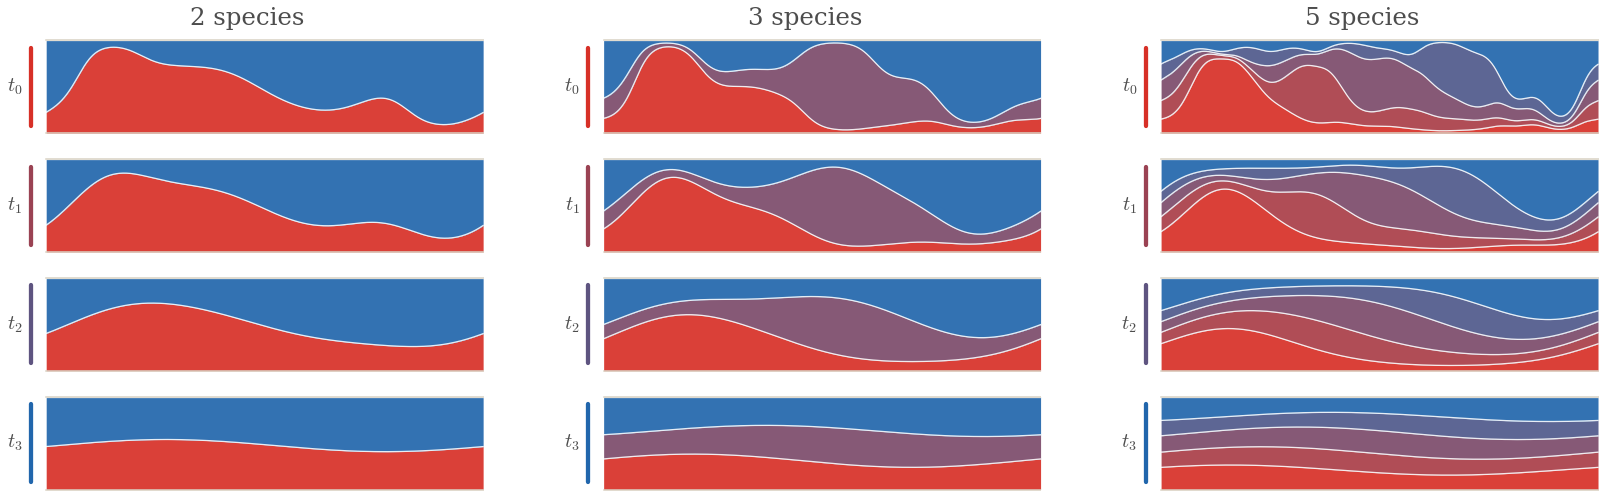

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.45))
for ax, p, label in zip(axes, [2, 3, 5], ["2 species", "3 species", "5 species"]):
    draw_panel(p, ax=ax)
    ax.text(0.5, 1.02, label, transform=ax.transAxes, ha="center", va="bottom", fontsize=8, color=GRAY)
fig.subplots_adjust(left=0.02, right=0.995, bottom=0.04, top=0.88, wspace=0.18)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

display(Image(filename=str(THUMB)))